In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
plt.style.use('fivethirtyeight')

In [6]:
end = datetime.now()
start = datetime(end.year-15, end.month, end.day)
stock = 'BTC-USD'
stock_data = yf.download(stock, start=start, end = end)
features = stock_data[['Open', 'High', 'Low', 'Close', 'Volume']]

NameError: name 'datetime' is not defined

In [80]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


In [82]:
stock_data.tail()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2025-04-22,93441.890625,93817.382812,87084.531250,87521.875000,55899038456
2025-04-23,93699.109375,94535.734375,91962.960938,93427.585938,41719568821
2025-04-24,93943.796875,94016.195312,91696.710938,93692.398438,31483175315
2025-04-25,94720.500000,95768.390625,92898.593750,93954.250000,40915232364
2025-04-26,94241.617188,95211.093750,93986.718750,94708.265625,18654304256


In [84]:
stock_data.describe().T

,,count,mean,std,min,25%,50%,75%,max
Price,Ticker,,,,,,,,
Close,BTC-USD,3875.0,2.174047e+04,2.504347e+04,1.781030e+02,1.771245e+03,9.693803e+03,3.552396e+04,1.061463e+05
High,BTC-USD,3875.0,2.219897e+04,2.555070e+04,2.117310e+02,1.822205e+03,9.887610e+03,3.644711e+04,1.091149e+05
Low,BTC-USD,3875.0,2.121235e+04,2.446335e+04,1.715100e+02,1.701275e+03,9.483004e+03,3.409856e+04,1.052917e+05
Open,BTC-USD,3875.0,2.171744e+04,2.502013e+04,1.768970e+02,1.749110e+03,9.691230e+03,3.550688e+04,1.061473e+05
Volume,BTC-USD,3875.0,1.929971e+10,2.082473e+10,5.914570e+06,7.649860e+08,1.545103e+10,3.052370e+10,3.509679e+11


In [86]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3875 entries, 2014-09-17 to 2025-04-26
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BTC-USD)   3875 non-null   float64
 1   (High, BTC-USD)    3875 non-null   float64
 2   (Low, BTC-USD)     3875 non-null   float64
 3   (Open, BTC-USD)    3875 non-null   float64
 4   (Volume, BTC-USD)  3875 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 181.6 KB


In [88]:
stock_data.columns

MultiIndex([( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])

In [90]:
#Close price data
closing_price = stock_data[['Close']]

In [92]:
closing_price['Close']

Ticker,BTC-USD
Date,
2014-09-17,457.334015
2014-09-18,424.440002
2014-09-19,394.795990
2014-09-20,408.903992
2014-09-21,398.821014
...,...
2025-04-22,93441.890625
2025-04-23,93699.109375
2025-04-24,93943.796875


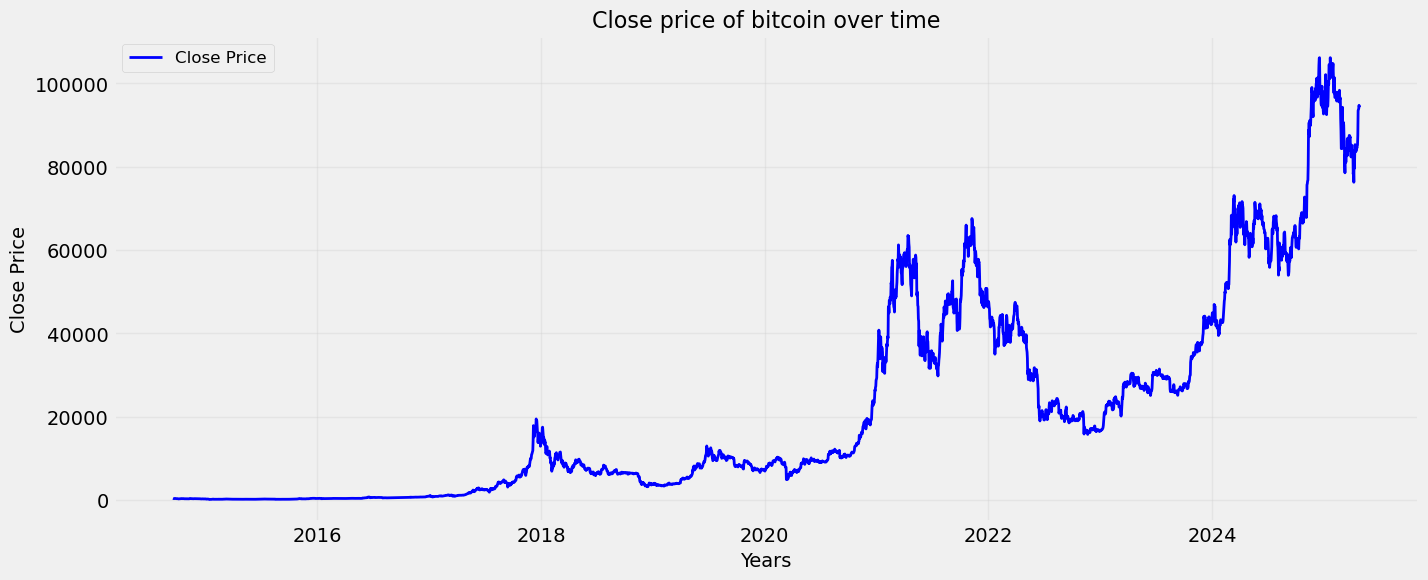

In [94]:
#Plot closing price with enchacement
plt.figure(figsize = (15, 6))
plt.plot(closing_price.index, closing_price['Close'], label = 'Close Price', color = 'blue', linewidth =2)
plt.title("Close price of bitcoin over time", fontsize = 16)
plt.xlabel("Years", fontsize = 14)
plt.ylabel('Close Price', fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()

In [96]:
# Moving Average
temp_data = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
# moving average for 5 day -> null null null null 30.0 40.0
print(sum(temp_data[1:6])/5)

40.0


In [98]:
df1 = pd.DataFrame(temp_data)

In [100]:
df1.rolling(5).mean()

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,30.0
5,40.0
6,50.0
7,60.0
8,70.0
9,80.0


In [102]:
for i in range(2014, 2024):
    print(i, list(stock_data.index.year).count(i))

2014 106
2015 365
2016 366
2017 365
2018 365
2019 365
2020 366
2021 365
2022 365
2023 365


In [104]:
closing_price['MA_365'] = closing_price['Close'].rolling(window = 365).mean()
closing_price['MA_100'] = closing_price['Close'].rolling(window = 100).mean()

/var/folders/fk/8t87f4t979d3z85yq371xrtr0000gn/T/ipykernel_81401/194502310.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_365'] = closing_price['Close'].rolling(window = 365).mean()
/var/folders/fk/8t87f4t979d3z85yq371xrtr0000gn/T/ipykernel_81401/194502310.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_100'] = closing_price['Close'].rolling(window = 100).mean()


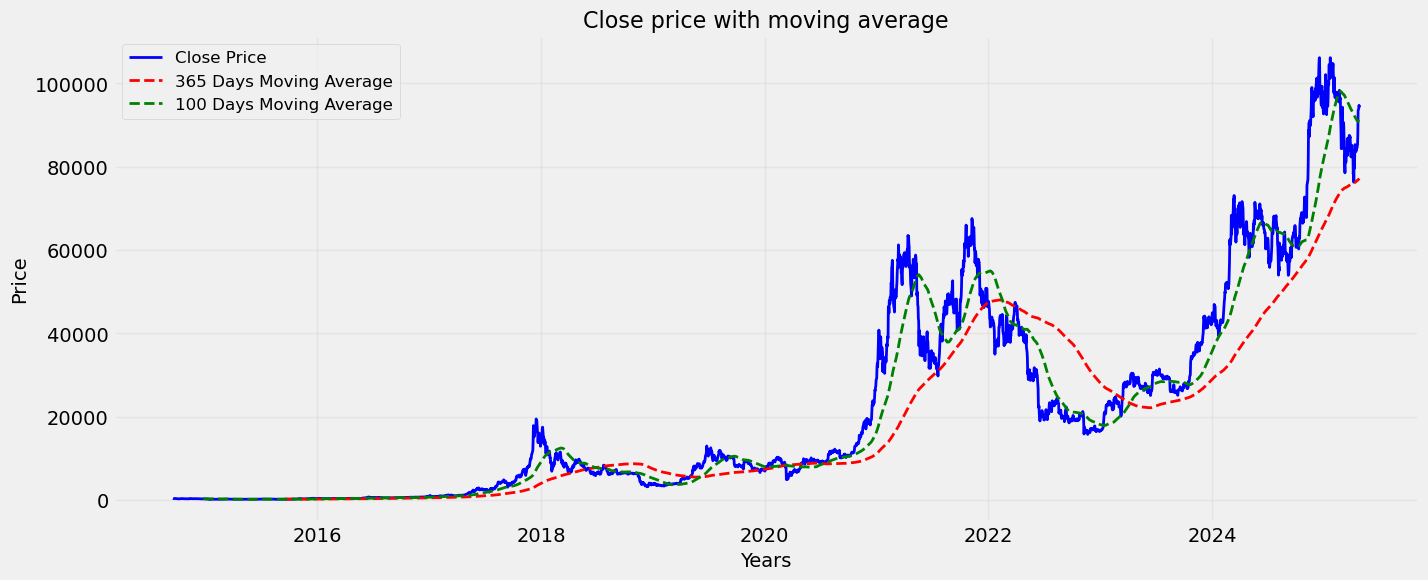

In [106]:
#Plot closing price with enchacement
plt.figure(figsize = (15, 6))
plt.plot(closing_price.index, closing_price['Close'], label = 'Close Price', color = 'blue', linewidth =2)
plt.plot(closing_price.index, closing_price['MA_365'], label = '365 Days Moving Average', color = 'red', linestyle ="--", linewidth =2)
plt.plot(closing_price.index, closing_price['MA_100'], label = '100 Days Moving Average', color = 'green',linestyle ="--", linewidth =2)

plt.title("Close price with moving average", fontsize = 16)
plt.xlabel("Years", fontsize = 14)
plt.ylabel('Price', fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()

In [108]:
# LSTM-> Long short term memory
# scale the data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(closing_price[['Close']].dropna())

In [110]:
len(scaled_data)

3875

In [112]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [114]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [116]:
# Prepare data for lstm
x_data = []
y_data = []
base_days =100
for i in range(base_days, len(scaled_data)):
    x_data.append(scaled_data[i-base_days: i])
    y_data.append(scaled_data[i])
x_data = np.array(x_data)
y_data = np.array(y_data)

In [118]:
# Split into train and test sets
train_size = int(len(x_data) * 0.9)
x_train , y_train = x_data[:train_size], y_data[:train_size]
x_test, y_test = x_data[train_size:], y_data[train_size:]

In [124]:
model = Sequential([
    LSTM(128, return_sequences = True, input_shape = (x_train.shape[1], 1)),
    LSTM(64, return_sequences = False),
    Dense(25),
    Dense(1)
])

model.compile(optimizer = "adam", loss = "mean_squared_error")
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,619 (459.45 KB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

In [126]:
model.fit(x_train, y_train, batch_size = 5, epochs = 10)

Epoch 1/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - loss: 0.0013
Epoch 2/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 25s 37ms/step - loss: 2.5446e-04
Epoch 3/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 25s 37ms/step - loss: 1.5730e-04
Epoch 4/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - loss: 1.7261e-04
Epoch 5/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - loss: 1.6074e-04
Epoch 6/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 27s 40ms/step - loss: 1.6300e-04
Epoch 7/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - loss: 1.3185e-04
Epoch 8/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - loss: 1.1779e-04
Epoch 9/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 27s 40ms/step - loss: 1.1831e-04
Epoch 10/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - loss: 1.4787e-04


In [4]:
predictions = model.predict(x_test)
inv_predictions = scaler.inverse_transform(predictions)
inv_y_test = scaler.inverse_transform(y_test)

NameError: name 'model' is not defined

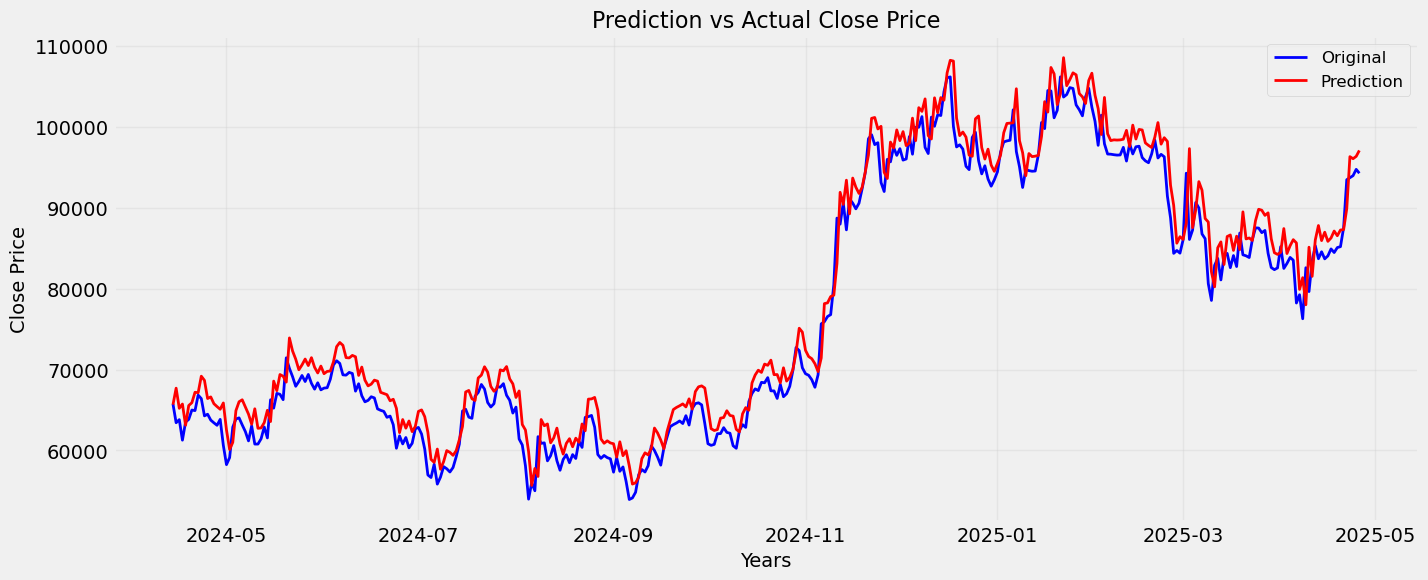

In [130]:
plotting_data = pd.DataFrame(
    {
        'Original': inv_y_test.flatten(), 
        'Prediction': inv_predictions.flatten(),
    }, index = closing_price.index[train_size + base_days:]
)

plt.figure(figsize = (15, 6))
plt.plot(plotting_data.index, plotting_data['Original'], label = 'Original', color = 'blue', linewidth =2)
plt.plot(plotting_data.index, plotting_data['Prediction'], label = 'Prediction', color = 'red',  linewidth =2)

plt.title("Prediction vs Actual Close Price", fontsize = 16)
plt.xlabel("Years", fontsize = 14)
plt.ylabel('Close Price', fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()

In [132]:
# Predict future days
last_100  = scaled_data[-100:].reshape(1, -1, 1)
future_predictions=[]
for _ in range(10):
    next_days = model.predict(last_100)
    future_predictions.append(scaler.inverse_transform(next_days))
    last_100 = np.append(last_100[:, 1:, :], next_days.reshape(1, 1, -1), axis = 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [134]:
future_predictions

[array([[96314.625]], dtype=float32),
 array([[98609.3]], dtype=float32),
 array([[100886.71]], dtype=float32),
 array([[103190.586]], dtype=float32),
 array([[105521.46]], dtype=float32),
 array([[107859.16]], dtype=float32),
 array([[110176.45]], dtype=float32),
 array([[112445.914]], dtype=float32),
 array([[114643.19]], dtype=float32),
 array([[116748.375]], dtype=float32)]

In [2]:
future_predictions = np.array(future_predictions).flatten()

plt.figure(figsize = (15, 6))
plt.plot(range(1, 11), future_predictions, marker="o" ,label = 'Prediction Future Prices', color = 'purple', linewidth =2)

for i, val in enumerate(future_predictions):
    plt.text(i+1,val,  f'{val:.2f}', fontsize = 10, ha = 'center', va = 'bottom', color='black')

plt.title("Future Close Prices for 10 Days", fontsize = 16)
plt.xlabel("Day Ahead", fontsize = 14)
plt.ylabel('Close Price', fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()

NameError: name 'np' is not defined

In [138]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(inv_y_test, inv_predictions)
mae = mean_absolute_error(inv_y_test, inv_predictions)

r2 = r2_score(inv_y_test, inv_predictions)
print("MSE Error:",mse)
print("MAE Error:",mae)
print("Accuracy:",r2*100)


MSE Error: 8238268.211303629
MAE Error: 2397.8875868055557
Accuracy: 96.6326524825921


In [200]:
model.save("BTC.keras")

In [202]:
model.save('/Users/aryanbansal/Desktop/BTC_jupyter/BTC.keras')